# Data Science Ethics Project (CS212)
### Project Description
Our project is a research paper algorithm implementation on the Healthcare AI Bias-Mitigation algorithm FairGrad. Our project focuses on fairness of AI models in healthcare. We will review current literature, including: (1) Wang & Yang (2025) on the FairGrad gradient reconciliation approach, (2) Mbakwe et al. (2023) on fairness metrics for health AI, (3) IRI et al. (2024) on a scientometric analysis of fairness in health AI literature, and (4) Ueda et al. (2024) on review and recommendations for fairness in healthcare AI. While AI can drastically improve healthcare, without safeguards it may amplify inequities present in training data and when models encode sensitive characteristics like race and sex this can lead to biased predictions that can worsen misdiagnosis and resource allocation for marginalized groups. A major roadblock is the Performance-Fairness trade off, where fairness gains often come at the cost of predictive accuracy. For this project, we will implement FairGrad (Wang & Yang, 2025), a “gradient reconciliation framework that automatically balances predictive performance with multi-attribute fairness optimization”(Wang & Yang, 2025). Our team will reproduce FairGrad from scratch and benchmark it against a standard logistic regression baseline on in-hospital mortality prediction in the MIMIC-IV sepsis cohort, assessing whether FairGrad improves equity as the paper proposes.

Referenced Research Paper: https://arxiv.org/abs/2504.14388

Repository: https://github.com/JGomez89/fairgrad-eval

### Contributions

| Teammate #  | Name | Primary Contribution |
|---|---|---|
| 1 | Justin Gomez | Teammate 1 will manage data access and preprocessing for the Sepsis dataset using a BigQuery connection. Following the procedures described in the paper, this work includes data cleaning, integration across relevant MIMIC-IV tables, and validation of dataset quality. Teammate 1 will also compare the distribution of positive and negative outcome classes, stratified by race and sex, between our derived dataset and the dataset described in the paper.The final output of this stage will be a de-identified, preprocessed dataset of approximately 9,349 records that is ready for model training.|
| 2 | Joshua Ranade | Teammate 2 will implement the FairGrad algorithm and train a PyTorch logistic regression model as a baseline “vanilla” classifier without fairness constraints. This baseline will allow us to measure the effect of fairness mitigation. If time permits, Teammate 2 will also implement two additional benchmark methods from the AI Fairness 360 (AIF360) Python library: adversarial debiasing and reduction-based fairness methods. These benchmarks will provide additional comparison points for evaluating FairGrad.|
| 3 | Anjali Gummuluri | Teammate 3 will conduct model evaluation using the results produced by the implemented methods. This includes assessing predictive performance and fairness outcomes using stratified 5-fold cross-validation. Performance evaluation metrics: Area Under the Receiver Operating Characteristic Curve (AUROC), Sensitivity, Specificity. Fairness evaluation metrics: Equalized Odds Difference, Performance–Fairness score |

## Explore MIMIC-IV Database

In [1]:
import pandas as pd
import numpy as np

# Import packages for BigQuery access
!pip install --upgrade google-cloud-bigquery
!pip install google-cloud-bigquery[bqstorage,pandas]
from google.cloud import bigquery
from google.colab import auth
from google.colab import drive

# Initialize BigQuery client connected to the MIMIC-IV-EXT-FAIRGRAD-EVAL project
auth.authenticate_user()
drive.mount('/content/drive')
client = bigquery.Client(project="mimic-iv-ext-fairgrad-eval")

def q(query_string):
    query_job = client.query(query_string)
    return query_job.to_dataframe()

Mounted at /content/drive


In [2]:
# In-hospital mortality
# Gender
# Age
# Race

q("""SELECT subject_id, hadm_id, stay_id, gender, admission_age, race, hospital_expire_flag, first_hosp_stay, first_icu_stay
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` 
WHERE subject_id IS NOT NULL
AND hadm_id IS NOT NULL
AND stay_id IS NOT NULL
AND gender IS NOT NULL
AND admission_age IS NOT NULL
AND race IS NOT NULL
AND hospital_expire_flag IS NOT NULL
LIMIT 10""")

,subject_id,hadm_id,stay_id,gender,admission_age,race,hospital_expire_flag,first_hosp_stay,first_icu_stay
0,10141487,24889188,39804513,F,18,UNKNOWN,0,True,True
1,10168562,20936196,30883841,F,18,WHITE,0,True,True
2,10307127,21399795,36366751,M,18,BLACK/AFRICAN AMERICAN,0,True,False
3,10307127,21399795,35486091,M,18,BLACK/AFRICAN AMERICAN,0,True,True
4,10391698,25190401,39250200,F,18,WHITE,0,True,True
5,10542217,22402134,37079602,M,18,WHITE,0,True,True
6,10561852,25577419,34454262,F,18,UNABLE TO OBTAIN,0,True,True
7,10562205,20149612,34317198,M,18,WHITE,0,True,True
8,10652259,24797020,33359917,M,18,UNKNOWN,0,True,True
9,10665087,25197235,30970959,F,18,UNKNOWN,0,True,True


In [3]:
# Heart Rate
# Glucose
# Systolic Blood Pressure (SBP)

q("""
SELECT subject_id, stay_id, heart_rate_min, heart_rate_max, 
heart_rate_mean, glucose_min, glucose_max, glucose_mean, sbp_min, 
sbp_max, sbp_mean 
FROM `physionet-data.mimiciv_3_1_derived.first_day_vitalsign` 
WHERE subject_id IS NOT NULL
and stay_id IS NOT NULL
and heart_rate_min IS NOT NULL
and heart_rate_max IS NOT NULL
and heart_rate_mean IS NOT NULL
and sbp_min IS NOT NULL
and sbp_max IS NOT NULL
and sbp_mean IS NOT NULL
and heart_rate_min IS NOT NULL
and heart_rate_max IS NOT NULL
and heart_rate_mean IS NOT NULL
and glucose_min IS NOT NULL
and glucose_max IS NOT NULL
and glucose_mean IS NOT NULL
LIMIT 10
""")

,subject_id,stay_id,heart_rate_min,heart_rate_max,heart_rate_mean,glucose_min,glucose_max,glucose_mean,sbp_min,sbp_max,sbp_mean
0,14106509,35818526,57.0,141.0,102.625000,64.0,73.0,68.5,44.0,97.0,80.600000
1,14356315,37003247,101.0,123.0,110.571429,81.0,81.0,81.0,75.0,125.0,100.000000
2,19349187,37874808,30.0,132.0,104.666667,83.0,83.0,83.0,76.0,113.0,92.333333
3,17513748,37283456,56.0,69.0,64.357143,84.0,84.0,84.0,101.0,156.0,117.666667
4,13630653,38685798,110.0,110.0,110.000000,79.0,85.0,82.0,195.0,195.0,195.000000
5,19948220,39201286,58.0,145.0,108.333333,97.0,97.0,97.0,72.0,201.0,134.400000
6,18102901,30488976,70.0,101.0,86.058824,113.0,113.0,113.0,104.0,132.0,117.444444
7,18265680,39346605,87.0,107.0,95.700000,116.0,116.0,116.0,109.0,145.0,120.000000
8,13788454,36414583,94.0,133.0,114.666667,122.0,122.0,122.0,59.0,108.0,81.000000
9,16324127,33732908,95.0,119.0,108.400000,127.0,127.0,127.0,30.0,118.0,85.000000


In [4]:
# Charlson Comorbidity Index (CCI)
q("""
SELECT subject_id, hadm_id, charlson_comorbidity_index 
FROM `physionet-data.mimiciv_3_1_derived.charlson` 
WHERE subject_id IS NOT NULL
AND hadm_id IS NOT NULL
AND charlson_comorbidity_index IS NOT NULL
LIMIT 10
""")

,subject_id,hadm_id,charlson_comorbidity_index
0,13521437,21043620,5
1,15754851,24589551,4
2,11869791,23452974,0
3,18828736,25260719,6
4,19300198,20183219,4
5,18151168,20556551,8
6,19585183,21531681,5
7,15862493,24138206,7
8,16231014,27637020,3
9,15767642,26994406,6


In [5]:
# APACHE-III score
q("""
SELECT subject_id, hadm_id, stay_id, apsiii
FROM `physionet-data.mimiciv_3_1_derived.apsiii` 
WHERE subject_id IS NOT NULL
AND hadm_id IS NOT NULL
AND stay_id IS NOT NULL
AND apsiii IS NOT NULL
LIMIT 10
""")


,subject_id,hadm_id,stay_id,apsiii
0,18944959,22112997,32694803,0
1,14766306,21640292,32321012,0
2,17676327,27456005,37960207,0
3,17784939,28330780,32000668,0
4,10971284,22087634,33084533,0
5,11618742,27083914,38146761,0
6,11033454,20410256,38852341,0
7,18857002,28090043,32379958,0
8,17861096,28033870,34455374,0
9,18016793,22565957,35019933,0


In [6]:
# Sepsis diagnosis criteria

q("""
SELECT
  di.subject_id, di.hadm_id,
  STRING_AGG(DISTINCT d.long_title, '; ' ORDER BY d.long_title) AS sepsis_dx_titles
FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` AS di
JOIN `physionet-data.mimiciv_3_1_hosp.d_icd_diagnoses` AS d
  ON di.icd_code = d.icd_code
 AND di.icd_version = d.icd_version
WHERE LOWER(d.long_title) LIKE '%sepsis%'
AND di.subject_id IS NOT NULL
AND di.hadm_id IS NOT NULL
GROUP BY di.subject_id, di.hadm_id
ORDER BY di.subject_id, di.hadm_id
LIMIT 10
""")

,subject_id,hadm_id,sepsis_dx_titles
0,10000826,21086876,Sepsis
1,10001401,27012892,Sepsis due to Enterococcus; Sepsis following a...
2,10001401,27060146,"Sepsis, unspecified organism"
3,10001843,26133978,"Sepsis, unspecified organism; Severe sepsis wi..."
4,10002013,24848509,Severe sepsis
5,10002013,25442395,"Sepsis, unspecified organism"
6,10002428,23473524,Sepsis
7,10002428,28662225,Severe sepsis
8,10003019,22774359,Severe sepsis
9,10003400,23559586,"Sepsis, unspecified organism; Severe sepsis wi..."


## Build Raw Sepsis Cohort from MIMIC-IV

In [1]:
import pandas as pd
import numpy as np

# Import packages for BigQuery access
!pip install --upgrade google-cloud-bigquery
!pip install google-cloud-bigquery[bqstorage,pandas]
from google.cloud import bigquery
from google.colab import auth
from google.colab import drive


### Recreating the researcher's sepsis cohort: 
Criteria:
- Must have sepsis
- Must be admitted to ED or ICU at Beth Israel Deaconess Medical Center
- No NULL values
- Race must be known

Features to join:
- In-hospital mortality (deceased vs. survived)
- Age
- Heart Rate
- Glucose
- Systolic Blood Pressure(SBP)
- Charlson Comorbidity Index (CCI)
- APACHE-III score
- Race
- Sex

In [2]:
# Initialize BigQuery client connected to the MIMIC-IV-EXT-FAIRGRAD-EVAL project
auth.authenticate_user()
drive.mount('/content/drive')
client = bigquery.Client(project="mimic-iv-ext-fairgrad-eval")

Mounted at /content/drive


In [3]:
def q(query_string):
    query_job = client.query(query_string)
    return query_job.to_dataframe()

### Join all relevant tables

Tables
- `physionet-data.mimiciv_3_1_hosp.diagnoses_icd`
- `physionet-data.mimiciv_3_1_hosp.d_icd_diagnoses`
- `physionet-data.mimiciv_3_1_derived.icustay_detail`
- `physionet-data.mimiciv_3_1_derived.first_day_vitalsign`
- `physionet-data.mimiciv_3_1_derived.charlson`
- `physionet-data.mimiciv_3_1_derived.apsiii`

Join On
- subject_id = patient (can have multiple hadm_id)
- hadm_id = hospital admission (can have multiple stay_id)
- stay_id = icu admission

In [4]:
# Join the sepsis diagnosis criteria to the full feature dataset to create a final dataset for modeling
# This will be the dataset we use for the rest of the project

df_raw=q("""WITH sepsis_patients AS (
  SELECT
    di.subject_id, di.hadm_id,
    STRING_AGG(DISTINCT d.long_title, '; ' ORDER BY d.long_title) AS sepsis_dx_titles
  FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` AS di
  JOIN `physionet-data.mimiciv_3_1_hosp.d_icd_diagnoses` AS d
    ON di.icd_code = d.icd_code
   AND di.icd_version = d.icd_version
  WHERE LOWER(d.long_title) LIKE '%sepsis%'
  AND di.subject_id IS NOT NULL
  AND di.hadm_id IS NOT NULL
  GROUP BY di.subject_id, di.hadm_id
)

SELECT 
  d.hospital_expire_flag, d.subject_id, d.hadm_id, d.stay_id, d.gender, d.admission_age, d.race, d.first_hosp_stay, d.first_icu_stay,
  v.heart_rate_min, v.heart_rate_max, v.heart_rate_mean,
  v.glucose_min, v.glucose_max, v.glucose_mean,
  v.sbp_min, v.sbp_max, v.sbp_mean,
  c.charlson_comorbidity_index,
  a.apsiii,
  s.sepsis_dx_titles
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` AS d
JOIN `physionet-data.mimiciv_3_1_derived.first_day_vitalsign` AS v
  ON d.subject_id = v.subject_id AND d.stay_id = v.stay_id
JOIN `physionet-data.mimiciv_3_1_derived.charlson` AS c
  ON d.subject_id = c.subject_id AND d.hadm_id = c.hadm_id
JOIN `physionet-data.mimiciv_3_1_derived.apsiii` AS a
  ON d.subject_id = a.subject_id AND d.hadm_id = a.hadm_id AND d.stay_id = a.stay_id
JOIN sepsis_patients AS s
  ON d.subject_id = s.subject_id AND d.hadm_id = s.hadm_id
WHERE d.subject_id IS NOT NULL
AND d.hadm_id IS NOT NULL
AND d.stay_id IS NOT NULL
AND d.gender IS NOT NULL
AND d.admission_age IS NOT NULL
AND d.race IS NOT NULL
AND d.hospital_expire_flag IS NOT NULL
AND d.first_hosp_stay IS NOT NULL
AND d.first_icu_stay IS NOT NULL
AND v.heart_rate_min IS NOT NULL
AND v.heart_rate_max IS NOT NULL
AND v.heart_rate_mean IS NOT NULL
AND v.glucose_min IS NOT NULL
AND v.glucose_max IS NOT NULL
AND v.glucose_mean IS NOT NULL
AND v.sbp_min IS NOT NULL
AND v.sbp_max IS NOT NULL
AND v.sbp_mean IS NOT NULL
AND c.charlson_comorbidity_index IS NOT NULL
AND a.apsiii IS NOT NULL""")

df_raw

,hospital_expire_flag,subject_id,hadm_id,stay_id,gender,admission_age,race,first_hosp_stay,first_icu_stay,heart_rate_min,...,heart_rate_mean,glucose_min,glucose_max,glucose_mean,sbp_min,sbp_max,sbp_mean,charlson_comorbidity_index,apsiii,sepsis_dx_titles
0,1,10024483,20025657,39381825,M,84,BLACK/AFRICAN AMERICAN,False,True,23.0,...,91.666667,135.0,135.0,135.000000,52.0,62.0,58.000000,11,99,Severe sepsis
1,1,12098036,23754843,30459034,M,82,BLACK/AFRICAN AMERICAN,True,True,91.0,...,106.548387,32.0,135.0,98.472222,83.0,166.0,112.406250,8,102,"Gram-negative sepsis, unspecified; Severe seps..."
2,0,14988897,23104484,37137134,F,61,WHITE,True,True,61.0,...,75.107143,126.0,136.0,131.000000,76.0,114.0,99.142857,5,51,Severe sepsis
3,0,11437346,22508947,30395378,F,25,WHITE,True,True,97.0,...,106.120000,118.0,140.0,129.000000,68.0,103.0,96.260870,2,37,Sepsis
4,1,12119555,21909650,37223791,M,67,BLACK/AFRICAN AMERICAN,False,True,36.0,...,122.294118,181.0,181.0,181.000000,44.0,109.0,64.600000,10,77,Severe sepsis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16716,0,12872850,28951019,33930900,F,71,WHITE,False,True,66.0,...,74.037037,77.0,419.0,240.000000,83.0,164.0,111.925926,11,59,"Sepsis, unspecified organism; Severe sepsis wi..."
16717,1,17150377,24304553,34613772,M,63,WHITE,True,True,81.0,...,90.884615,147.0,454.0,273.750000,87.0,117.0,100.160000,12,67,Severe sepsis
16718,0,15295867,22606425,33885124,M,63,WHITE,False,True,58.0,...,71.586207,41.0,468.0,223.863636,91.0,134.0,103.206897,7,70,"Sepsis, unspecified organism; Severe sepsis wi..."
16719,1,16634427,20933199,36846845,F,56,BLACK/AFRICAN AMERICAN,False,True,115.0,...,115.000000,536.0,539.0,537.500000,149.0,149.0,149.000000,6,26,Other specified sepsis


## Clean and Preprocess Raw Data

In [5]:
import pandas as pd

The raw dataset contains duplicate patients because of multiple seperate ICU visits

Every row in the dataset should correspond to a unique subject_id
- shuffle the dataset
- only take the first instance of that subject_id, thus dropping all other duplicates of that id

In [6]:
# The raw dataset contains duplicate patients because of multiple seperate ICU visits
# Every row in the dataset should correspond to a unique subject_id
# So shuffle the dataset and only take the first instance of that subject_id, thus dropping all other duplicates of that id

df_unique = (df_raw
             .sample(frac=1, random_state=42)  # random shuffle
             .drop_duplicates(subset='subject_id', keep='first')
             .reset_index(drop=True))

print(f"Rows removed: {len(df_raw)-len(df_unique)}")
print(f"Rows remaining:  {len(df_unique)}")
print(f"Unique subject_ids: {df_unique['subject_id'].nunique()}")

Rows removed: 4765
Rows remaining:  11956
Unique subject_ids: 11956


In [7]:
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11956 entries, 0 to 11955
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   hospital_expire_flag        11956 non-null  Int64  
 1   subject_id                  11956 non-null  Int64  
 2   hadm_id                     11956 non-null  Int64  
 3   stay_id                     11956 non-null  Int64  
 4   gender                      11956 non-null  object 
 5   admission_age               11956 non-null  Int64  
 6   race                        11956 non-null  object 
 7   first_hosp_stay             11956 non-null  boolean
 8   first_icu_stay              11956 non-null  boolean
 9   heart_rate_min              11956 non-null  float64
 10  heart_rate_max              11956 non-null  float64
 11  heart_rate_mean             11956 non-null  float64
 12  glucose_min                 11956 non-null  float64
 13  glucose_max                 119

#### Cleaning tasks

Drop columns:
- sepsis_dx_titles
- first_hosp_stay
- first_icu_stay

Rename columns:
- hospital_expire_flag -> target
- admission_age -> age
- charlson_comorbidity_index -> cci

Change types:
- gender: object -> Int64
- race: object -> Int64

In [8]:
# All unique races to categorize into White vs Non-White

q("""
SELECT DISTINCT race
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail`
""")

,race
0,UNKNOWN
1,WHITE
2,BLACK/AFRICAN AMERICAN
3,UNABLE TO OBTAIN
4,ASIAN - CHINESE
5,HISPANIC/LATINO - DOMINICAN
6,OTHER
7,HISPANIC OR LATINO
8,NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER
9,WHITE - OTHER EUROPEAN


In [9]:
df_clean = df_unique.copy()

# Drop columns
df_clean.drop(columns=['subject_id','hadm_id', 'stay_id','sepsis_dx_titles', 'first_hosp_stay', 'first_icu_stay'], inplace=True)

# Rename columns
df_clean.rename(columns={
    'hospital_expire_flag': 'target',
    'admission_age': 'age',
    'charlson_comorbidity_index': 'cci'}, inplace=True)

# Encode gender: Male=1, Female=0
df_clean['gender'] = df_clean['gender'].map({'M': 1, 'F': 0}).astype('Int64')

# Encode race
def categorize_race(race_str):
    race_str = str(race_str).upper()
    if 'WHITE' in race_str:
        return 1
    elif race_str in ['UNKNOWN', 'PATIENT DECLINED TO ANSWER', 'UNABLE TO OBTAIN']:
        return None
    else:
        return 0
    
df_clean['race'] = df_clean['race'].apply(categorize_race)
df_clean = df_clean.dropna(subset=['race'])
df_clean['race'] = df_clean['race'].astype('Int64')

# Reset index
df_clean.reset_index(drop=True, inplace=True)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10504 entries, 0 to 10503
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   target           10504 non-null  Int64  
 1   gender           10504 non-null  Int64  
 2   age              10504 non-null  Int64  
 3   race             10504 non-null  Int64  
 4   heart_rate_min   10504 non-null  float64
 5   heart_rate_max   10504 non-null  float64
 6   heart_rate_mean  10504 non-null  float64
 7   glucose_min      10504 non-null  float64
 8   glucose_max      10504 non-null  float64
 9   glucose_mean     10504 non-null  float64
 10  sbp_min          10504 non-null  float64
 11  sbp_max          10504 non-null  float64
 12  sbp_mean         10504 non-null  float64
 13  cci              10504 non-null  Int64  
 14  apsiii           10504 non-null  Int64  
dtypes: Int64(6), float64(9)
memory usage: 1.3 MB


In [10]:
df_clean.describe()

,target,gender,age,race,heart_rate_min,heart_rate_max,heart_rate_mean,glucose_min,glucose_max,glucose_mean,sbp_min,sbp_max,sbp_mean,cci,apsiii
count,10504.0,10504.0,10504.0,10504.0,10504.000000,10504.000000,10504.000000,10504.000000,10504.000000,10504.000000,10504.000000,10504.000000,10504.000000,10504.0,10504.0
mean,0.288842,0.546554,67.587966,0.741813,76.147087,112.048648,91.718167,113.368717,572.022515,242.533857,83.965596,142.372572,110.656166,5.834063,58.83035
std,0.453246,0.497852,15.817158,0.437658,16.884596,22.557760,17.242103,43.715959,19508.144307,5731.597788,16.378552,23.447930,14.339904,3.08096,23.687546
min,0.0,0.0,18.0,0.0,3.000000,46.000000,40.538462,6.000000,18.000000,15.000000,0.108000,62.000000,39.153846,0.0,4.0
25%,0.0,0.0,58.0,0.0,64.000000,96.000000,79.090909,88.000000,123.000000,107.500000,75.000000,126.000000,101.075549,4.0,42.0
50%,0.0,1.0,69.0,1.0,75.000000,111.000000,91.012500,107.000000,159.000000,132.041667,84.000000,139.000000,108.292892,6.0,55.0
75%,1.0,1.0,80.0,1.0,87.000000,126.000000,103.500000,131.000000,221.000000,170.666667,93.000000,155.000000,117.825980,8.0,72.0
max,1.0,1.0,103.0,1.0,147.000000,227.000000,162.428571,950.000000,999999.000000,500037.500000,184.000000,336.000000,217.750000,19.0,180.0


##### Comments:
- glucose_max: 1.276100e+06 (MAX)	
- glucose_mean: 500048.500000 (MAX)

These are obvious errors, corroborated by the feature's std. 29812.04 and 7379.842060 respectively 


In [11]:
df_clean = df_clean[
    (df_clean['glucose_max'] < 2000) &
    (df_clean['glucose_mean'] < 2000) &
    (df_clean['glucose_min'] > 0) 
    # (df_clean['sbp_min'] > 20) &
    # (df_clean['heart_rate_min'] > 20) &
    # (df_clean['heart_rate_max'] < 250) &
    # (df_clean['apsiii'] <= 163) &
    # (df_clean['sbp_max'] <= 300)
]

print(f"Rows removed: {len(df_unique) - len(df_clean)}")
print(f"Rows remaining: {len(df_clean)}")

df_clean.describe()

Rows removed: 1460
Rows remaining: 10496


,target,gender,age,race,heart_rate_min,heart_rate_max,heart_rate_mean,glucose_min,glucose_max,glucose_mean,sbp_min,sbp_max,sbp_mean,cci,apsiii
count,10496.0,10496.0,10496.0,10496.0,10496.000000,10496.000000,10496.000000,10496.000000,10496.000000,10496.000000,10496.000000,10496.000000,10496.000000,10496.0,10496.0
mean,0.288586,0.546589,67.582412,0.741806,76.142721,112.036966,91.710239,113.383289,190.219750,146.772083,83.974526,142.367235,110.655864,5.833746,58.811928
std,0.453127,0.497848,15.817283,0.437662,16.880626,22.547380,17.236183,43.722658,110.206749,57.115268,16.373931,23.447275,14.341837,3.081007,23.668665
min,0.0,0.0,18.0,0.0,3.000000,46.000000,40.538462,6.000000,18.000000,15.000000,0.108000,62.000000,39.153846,0.0,4.0
25%,0.0,0.0,58.0,0.0,64.000000,96.000000,79.090909,88.000000,123.000000,107.500000,75.000000,126.000000,101.071429,4.0,42.0
50%,0.0,1.0,69.0,1.0,75.000000,111.000000,91.000000,107.000000,158.000000,132.000000,84.000000,139.000000,108.292892,6.0,55.0
75%,1.0,1.0,80.0,1.0,87.000000,126.000000,103.480000,131.000000,221.000000,170.500000,93.000000,155.000000,117.825980,8.0,72.0
max,1.0,1.0,103.0,1.0,147.000000,227.000000,162.428571,950.000000,1888.000000,950.000000,184.000000,336.000000,217.750000,19.0,180.0


In [12]:
df_sepsis = df_clean.copy().reset_index(drop=True)
df_sepsis

,target,gender,age,race,heart_rate_min,heart_rate_max,heart_rate_mean,glucose_min,glucose_max,glucose_mean,sbp_min,sbp_max,sbp_mean,cci,apsiii
0,0,1,88,1,71.0,118.0,87.074074,110.0,142.0,122.714286,90.0,145.0,118.093750,7,52
1,0,1,54,0,81.0,114.0,90.821429,82.0,350.0,183.769231,96.0,154.0,125.680000,4,47
2,0,0,78,0,86.0,133.0,110.038462,87.0,221.0,163.714286,81.0,144.0,105.166667,8,71
3,0,0,67,1,58.0,91.0,74.200000,117.0,129.0,123.333333,93.0,158.0,122.000000,4,25
4,1,1,76,1,59.0,88.0,70.680000,81.0,183.0,119.000000,60.0,111.0,85.844444,6,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10491,1,1,82,1,69.0,88.0,75.785714,136.5,136.5,136.500000,100.0,117.0,104.800000,7,80
10492,0,0,52,0,117.0,146.0,131.291667,126.0,300.0,242.666667,73.0,129.0,101.208333,9,94
10493,1,0,79,1,91.0,107.0,96.416667,79.0,87.0,84.000000,73.0,140.0,91.916667,6,52
10494,0,0,86,1,60.0,126.0,84.590909,72.0,79.0,75.500000,105.0,160.0,132.842105,6,49


In [13]:
features = {
    'Race': {
        'White':     lambda df: df['race'] == 1,
        'Non-White': lambda df: df['race'] == 0,
    },
    'Sex': {
        'Male':   lambda df: df['gender'] == 1,
        'Female': lambda df: df['gender'] == 0,
    }
}

def distribution_table(df, target_col, features):
    rows = []
    
    neg = df[df[target_col] == 0]
    pos = df[df[target_col] == 1]
    
    for feature, categories in features.items():
        rows.append({'Characteristic': feature, 'Overall': '', 'Neg. Class (Survived)': '', 'Pos. Class (Died)': ''})
        for label, condition in categories.items():
            overall_n = condition(df).sum()
            neg_n = condition(neg).sum()
            pos_n = condition(pos).sum()
            
            overall_pct = overall_n / len(df) * 100
            neg_pct = neg_n / len(neg) * 100
            pos_pct = pos_n / len(pos) * 100
            
            rows.append({
                'Characteristic': f'  {label}',
                'Overall': f'{overall_n:,} ({overall_pct:.1f}%)',
                'Neg. Class (Survived)': f'{neg_n:,} ({neg_pct:.1f}%)',
                'Pos. Class (Died)': f'{pos_n:,} ({pos_pct:.1f}%)'
            })
    
    table = pd.DataFrame(rows).set_index('Characteristic')
    
    table.columns = [
        f'Overall (N={len(df):,})',
        f'Neg. Class (N={len(neg):,})',
        f'Pos. Class (N={len(pos):,})'
    ]
    
    return table


distribution_table(df_sepsis, 'target', features)

,"Overall (N=10,496)","Neg. Class (N=7,467)","Pos. Class (N=3,029)"
Characteristic,,,
Race,,,
White,"7,786 (74.2%)","5,516 (73.9%)","2,270 (74.9%)"
Non-White,"2,710 (25.8%)","1,951 (26.1%)",759 (25.1%)
Sex,,,
Male,"5,737 (54.7%)","4,051 (54.3%)","1,686 (55.7%)"
Female,"4,759 (45.3%)","3,416 (45.7%)","1,343 (44.3%)"


In [14]:
df_sepsis.to_csv('/content/drive/MyDrive/df_sepsis.csv', index=False)

## Exploritory Data Analysis (EDA)

Shape: (10496, 15)


,target,gender,age,race,heart_rate_min,heart_rate_max,heart_rate_mean,glucose_min,glucose_max,glucose_mean,sbp_min,sbp_max,sbp_mean,cci,apsiii
0,0,1,88,1,71.0,118.0,87.074074,110.0,142.0,122.714286,90.0,145.0,118.093750,7,52
1,0,1,54,0,81.0,114.0,90.821429,82.0,350.0,183.769231,96.0,154.0,125.680000,4,47
2,0,0,78,0,86.0,133.0,110.038462,87.0,221.0,163.714286,81.0,144.0,105.166667,8,71
3,0,0,67,1,58.0,91.0,74.200000,117.0,129.0,123.333333,93.0,158.0,122.000000,4,25
4,1,1,76,1,59.0,88.0,70.680000,81.0,183.0,119.000000,60.0,111.0,85.844444,6,53


Dtypes:


,0
target,Int64
gender,Int64
age,Int64
race,Int64
heart_rate_min,float64
heart_rate_max,float64
heart_rate_mean,float64
glucose_min,float64
glucose_max,float64
glucose_mean,float64


Columns with missing values:


,0


,count,rate
Survived (0),7467,0.711414
Died (1),3029,0.288586


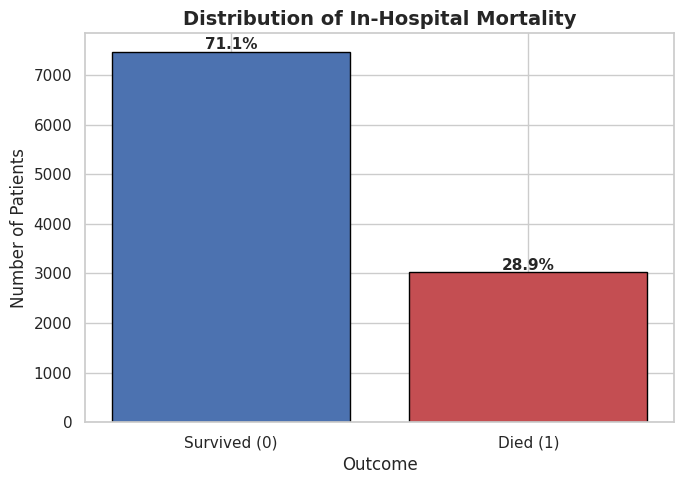

,race,count,positive_rate,positive_rate_pct
0,Non-White,2710,0.280074,28.00738
1,White,7786,0.291549,29.154893


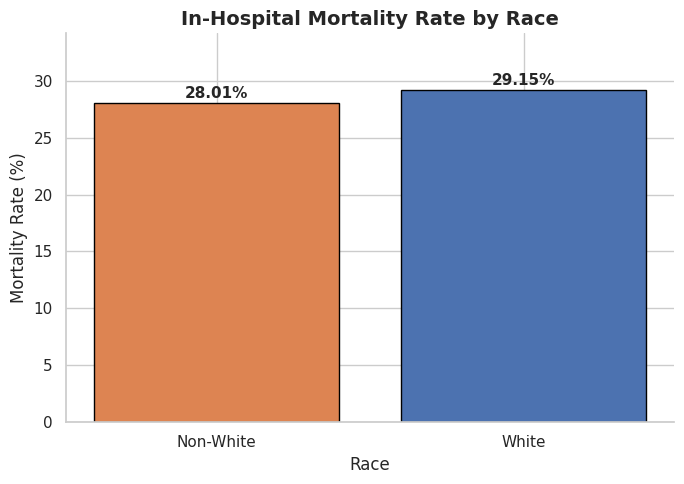

,gender,count,positive_rate,positive_rate_pct
0,Female,4759,0.282202,28.220214
1,Male,5737,0.293882,29.388182


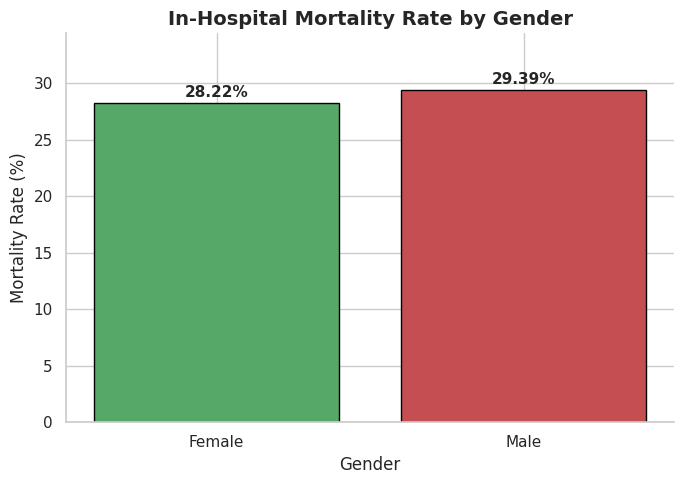

,count,positive_rate,positive_rate_pct
race_gender,,,
White / Male,4378,0.296254,29.6254
Non-White / Male,1359,0.28624,28.623988
White / Female,3408,0.285505,28.550469
Non-White / Female,1351,0.273871,27.387121


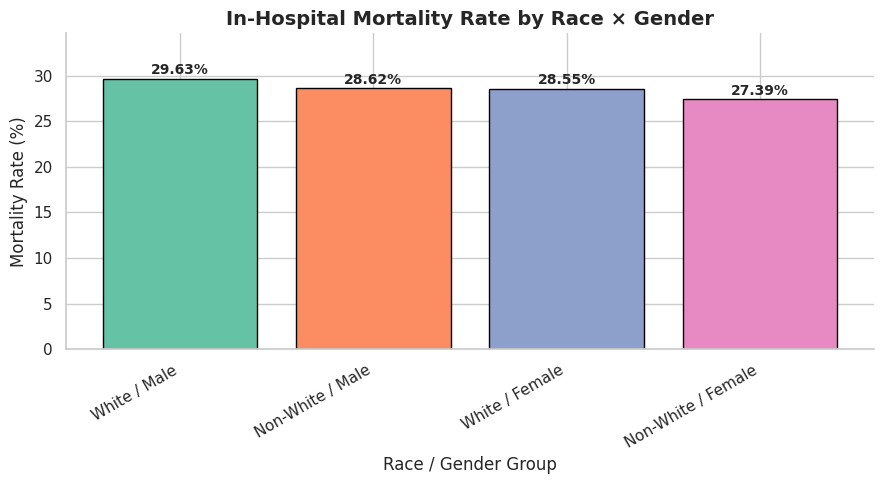

Key features: ['age', 'apsiii', 'cci']


/tmp/ipykernel_1015/3876155375.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


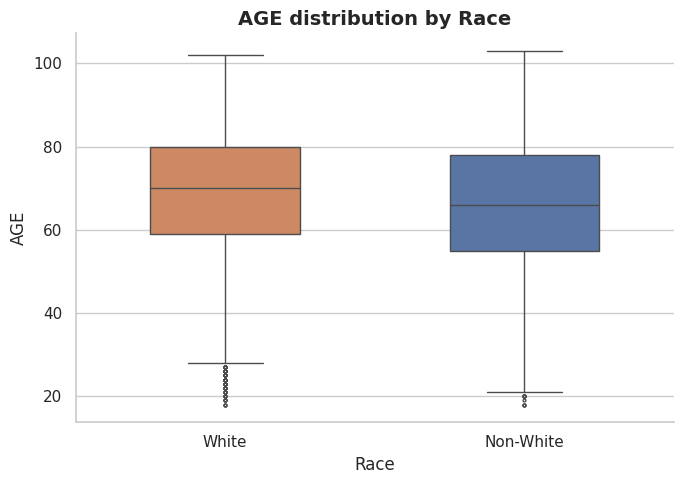

/tmp/ipykernel_1015/3876155375.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


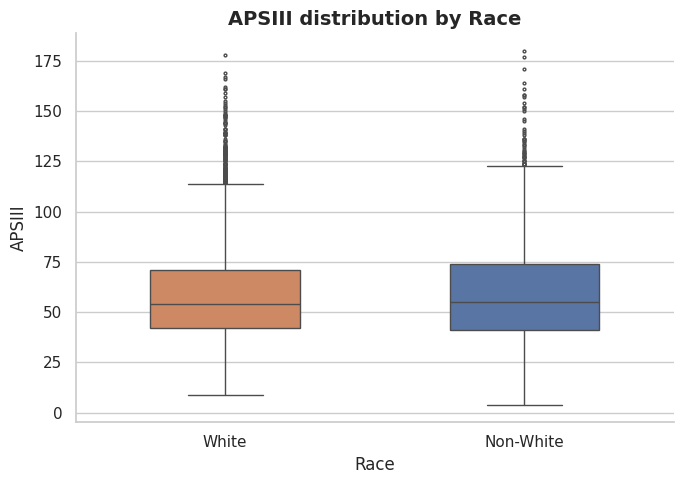

/tmp/ipykernel_1015/3876155375.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


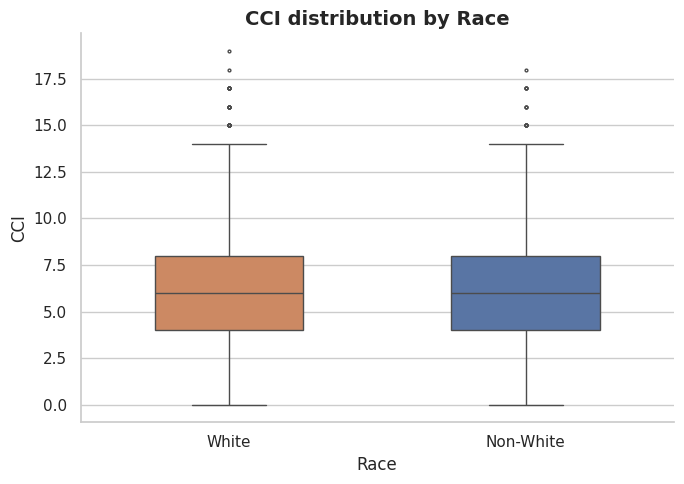

/tmp/ipykernel_1015/3876155375.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


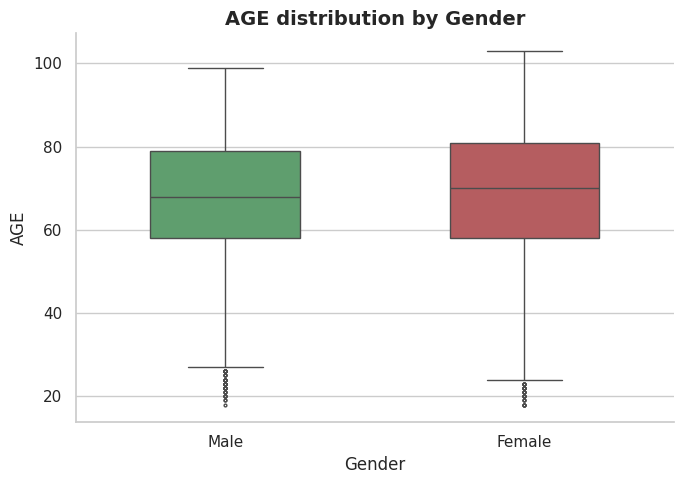

/tmp/ipykernel_1015/3876155375.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


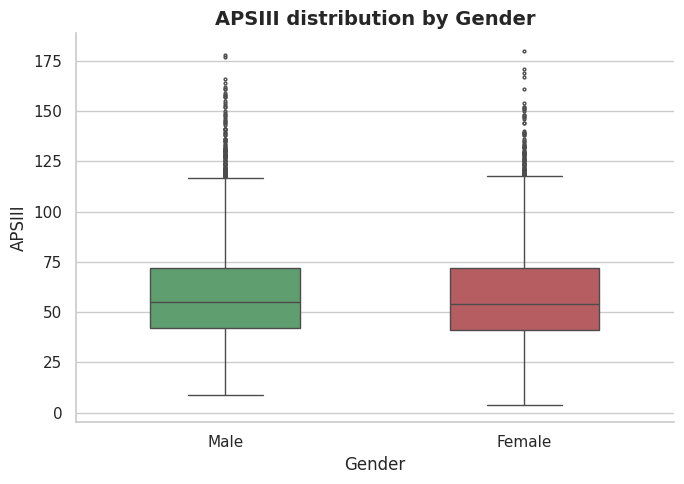

/tmp/ipykernel_1015/3876155375.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


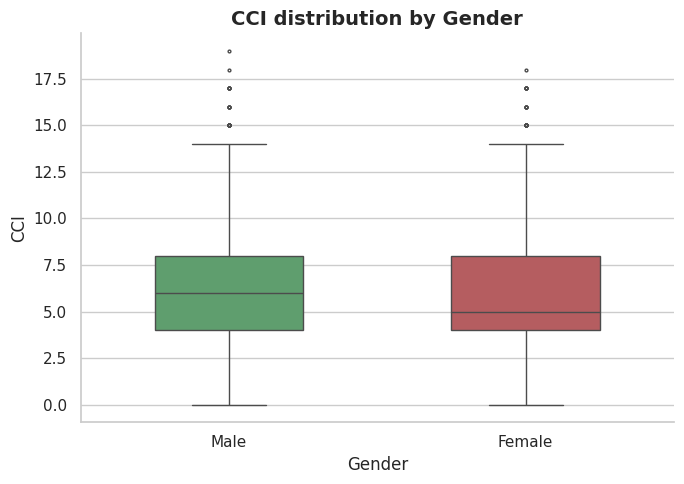

,group,group_value,feature,mean,std,median
0,race,0,age,64.959041,16.788002,66.0
1,race,0,apsiii,59.575646,24.873382,55.0
2,race,0,cci,5.864576,3.220648,6.0
3,race,1,age,68.495505,15.361490,70.0
4,race,1,apsiii,58.546108,23.230464,54.0
5,race,1,cci,5.823016,3.031034,6.0


,group,group_value,feature,mean,std,median
0,gender,0,age,67.939903,16.563676,70.0
1,gender,0,apsiii,58.570078,23.587871,54.0
2,gender,0,cci,5.621769,3.036806,5.0
3,gender,1,age,67.285864,15.165355,68.0
4,gender,1,apsiii,59.012550,23.735662,55.0
5,gender,1,cci,6.009587,3.106503,6.0


In [21]:
# TEAMMATE 2- 862554121

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# DATA_PATH = r"/content/df_sepsis.csv"
# df = pd.read_csv(DATA_PATH)
df=df_sepsis
print("Shape:", df.shape)
display(df.head())
TARGET_COL = "target"
SENSITIVE_COLS = ["race", "gender"]

assert TARGET_COL in df.columns
for c in SENSITIVE_COLS:
    assert c in df.columns

print("Dtypes:")
display(df.dtypes)

missing = df.isna().mean().sort_values(ascending=False)
print("Columns with missing values:")
display(missing[missing > 0])
#Exploratory Data Analysis
import seaborn as sns
counts = df[TARGET_COL].value_counts().sort_index()
rates = counts / counts.sum()
summary = pd.DataFrame({"count": counts, "rate": rates})
summary.index = ["Survived (0)", "Died (1)"]
display(summary)
sns.set(style="whitegrid")
plt.figure(figsize=(7, 5))
colors = ["#4C72B0", "#C44E52"]
bars = plt.bar(summary.index, summary["count"], color=colors, edgecolor="black")
plt.title("Distribution of In-Hospital Mortality", fontsize=14, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=12)
plt.xlabel("Outcome", fontsize=12)
for bar, rate in zip(bars, summary["rate"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f"{rate*100:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )
plt.tight_layout()
plt.show()
# target = 0 → patient survived hospital stay

# target = 1 → patient died in hospital

# This means

# 71.3% survived

# 28.7% died
#Outcome rate by race and gender
sns.set(style="whitegrid")
def group_outcome(df, s_col):
    t = df.groupby(s_col)[TARGET_COL].agg(["count", "mean"]).rename(columns={"mean":"positive_rate"})
    t["positive_rate_pct"] = 100 * t["positive_rate"]
    return t.reset_index()

for s in SENSITIVE_COLS:
    g = group_outcome(df, s)
    if s == "race":
        g[s] = g[s].map({0: "Non-White", 1: "White"})
        title_label = "Race"
        colors = ["#DD8452", "#4C72B0"]
    elif s == "gender":
        g[s] = g[s].map({0: "Female", 1: "Male"})
        title_label = "Gender"
        colors = ["#55A868", "#C44E52"]
    else:
        title_label = s
        colors = None
    display(g)
    plt.figure(figsize=(7, 5))
    bars = plt.bar(g[s], g["positive_rate_pct"], color=colors, edgecolor="black")
    plt.title(f"In-Hospital Mortality Rate by {title_label}", fontsize=14, fontweight="bold")
    plt.ylabel("Mortality Rate (%)", fontsize=12)
    plt.xlabel(title_label, fontsize=12)
    plt.ylim(0, max(g["positive_rate_pct"]) + 5)
    for bar, val in zip(bars, g["positive_rate_pct"]):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val:.2f}%",
            ha="center",
            fontsize=11,
            fontweight="bold"
        )

    sns.despine()
    plt.tight_layout()
    plt.show()
# Non-White mortality: 28.09%

# White mortality: 28.87%

# Female mortality: 28.28%

# Male mortality: 28.99%
sns.set(style="whitegrid")
df_inter = df.copy()
df_inter["race_label"] = df_inter["race"].map({0: "Non-White", 1: "White"})
df_inter["gender_label"] = df_inter["gender"].map({0: "Female", 1: "Male"})

df_inter["race_gender"] = df_inter["race_label"] + " / " + df_inter["gender_label"]
inter = (
    df_inter
    .groupby("race_gender")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"mean": "positive_rate"})
)

inter["positive_rate_pct"] = 100 * inter["positive_rate"]
#Sorting by mortality rate
inter = inter.sort_values("positive_rate_pct", ascending=False)

display(inter)
plt.figure(figsize=(9, 5))

colors = sns.color_palette("Set2", len(inter))

bars = plt.bar(inter.index, inter["positive_rate_pct"], color=colors, edgecolor="black")

plt.title("In-Hospital Mortality Rate by Race × Gender", fontsize=14, fontweight="bold")
plt.ylabel("Mortality Rate (%)", fontsize=12)
plt.xlabel("Race / Gender Group", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, max(inter["positive_rate_pct"]) + 5)
for bar, val in zip(bars, inter["positive_rate_pct"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{val:.2f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )
sns.despine()
plt.tight_layout()
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

KEY_FEATURES = [c for c in ["age", "apsiii", "cci"] if c in df.columns]
print("Key features:", KEY_FEATURES)

LABEL_MAPS = {
    "race": {0: "Non-White", 1: "White"},
    "gender": {0: "Female", 1: "Male"}
}

COLOR_MAPS = {
    "race": ["#DD8452", "#4C72B0"],
    "gender": ["#55A868", "#C44E52"]
}

def pretty_boxplot_by_group(df, feature, group_col):
    d = df[[feature, group_col]].dropna().copy()
    d[group_col] = d[group_col].map(LABEL_MAPS.get(group_col, {0: "0", 1: "1"}))

    plt.figure(figsize=(7, 5))
    ax = sns.boxplot(
        data=d,
        x=group_col,
        y=feature,
        palette=COLOR_MAPS.get(group_col, None),
        width=0.5,
        fliersize=2
    )

    ax.set_title(f"{feature.upper()} distribution by {group_col.capitalize()}",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel(group_col.capitalize(), fontsize=12)
    ax.set_ylabel(feature.upper(), fontsize=12)

    sns.despine()
    plt.tight_layout()
    plt.show()

for s in SENSITIVE_COLS:
    for f in KEY_FEATURES:
        pretty_boxplot_by_group(df, f, s)
def group_stats(df, group_col, features):
    out = []
    for g, sub in df.groupby(group_col):
        for f in features:
            out.append({
                "group": group_col,
                "group_value": int(g),
                "feature": f,
                "mean": sub[f].mean(),
                "std": sub[f].std(),
                "median": sub[f].median()
            })
    return pd.DataFrame(out)

for s in SENSITIVE_COLS:
    display(group_stats(df, s, KEY_FEATURES))

## Implement Fairgrad Algorithm

In [15]:
"""
FairGrad: Multi-Attribute Fair Gradient Reconciliation
Wang & Yang (2025), arXiv:2504.14388v1

PyTorch implementation — autograd computes all gradients automatically.
The reconciliation step intercepts .grad tensors before any optimizer step,
reconciles them across tasks, then applies the combined update manually.
"""

import torch
import torch.nn as nn
import numpy as np


class FairGrad:
    """
    Sklearn-compatible logistic regression trained with FairGrad gradient
    reconciliation. PyTorch handles the forward pass and gradient computation
    via autograd; reconciliation and parameter updates are applied manually.

    Usage:
        model = FairGrad(fairness_col_indices=[12, 13], lr=0.01, epochs=100)
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
    """

    def __init__(self, fairness_col_indices=None, lr=0.01, epochs=100):
        self.fairness_col_indices = fairness_col_indices or []
        self.lr                   = lr
        self.epochs               = epochs
        self.network              = None # nn.Linear, initialised in fit()

    def _build_network(self, n_features):
        return nn.Sequential(
            nn.Linear(n_features, 1),
            nn.Sigmoid()
        )

    def _forward(self, X_tensor):
        return self.network(X_tensor).squeeze()

    # ── Task losses ───────────────────────────────────────────────────────────

    @staticmethod
    def _loss_performance(y_hat, y):
        """Q_P: binary cross-entropy loss (Eq. 1). PyTorch computes ∇Q_P."""
        return nn.functional.binary_cross_entropy(y_hat, y)

    @staticmethod
    def _loss_fairness(y_hat, y, sensitive):
        """
        Q_F: soft EOD loss (Eq. 2). Uses float masks instead of boolean
        indexing so the computation graph stays intact for autograd.
        """
        eps    = 1e-15
        pos    = (y == 1).float()
        neg    = (y == 0).float()
        mask_a = (sensitive == 1).float()
        mask_b = (sensitive == 0).float()

        # Weighted average: sum(ŷ * mask) / sum(mask) — keeps gradients flowing
        wavg   = lambda mask: (y_hat * mask).sum() / (mask.sum() + eps)

        tpr_a, tpr_b = wavg(pos * mask_a), wavg(pos * mask_b)
        fpr_a, fpr_b = wavg(neg * mask_a), wavg(neg * mask_b)

        return 0.5 * (tpr_a - tpr_b)**2 + 0.5 * (fpr_a - fpr_b)**2

    # ── Gradient extraction ───────────────────────────────────────────────────

    def _extract_gradient(self, loss):
        """
        Run one backward pass for a single task loss and return all parameter
        gradients as one flat vector. Each call needs its own forward pass —
        sharing a y_hat across losses frees the graph after the first .backward().
        """
        self.network.zero_grad()
        loss.backward()
        return torch.cat([p.grad.clone().flatten() for p in self.network.parameters()])

    # ── Algorithm 1: gradient reconciliation ─────────────────────────────────

    @staticmethod
    def _reconcile(gradients):
        """
        For each v_m, remove any component that conflicts with u_n (Eq. 4):
            if v_m · u_n < 0:  v_m ← v_m − (v_m · u_n / ‖u_n‖²) u_n
        Returns Δw = Σ v_m  (Eq. 5).
        """
        u = gradients
        v = [g.clone() for g in u]

        for m in range(len(u)):
            others = list(range(len(u)))
            others.remove(m)
            np.random.shuffle(others)               # random permutation avoids ordering bias
            for n in others:
                dot = torch.dot(v[m], u[n])
                if dot < 0:                         # conflict: these gradients oppose each other
                    v[m] = v[m] - (dot / (torch.dot(u[n], u[n]) + 1e-15)) * u[n]

        return sum(v)                               # Δw = Σ v_m

    # ── Manual parameter update ───────────────────────────────────────────────

    def _apply_update(self, delta_w):
        """
        w ← w − η Δw  (Eq. 6).
        Since we bypassed the optimizer, we update parameters manually
        inside torch.no_grad() to avoid building a new computation graph.
        """
        idx = 0
        with torch.no_grad():
            for p in self.network.parameters():
                numel = p.numel()
                p = p - self.lr * delta_w[idx : idx + numel].reshape(p.shape)
                idx += numel

    # ── Sklearn API ───────────────────────────────────────────────────────────

    def fit(self, X, y):
        X = torch.tensor(np.array(X, dtype=np.float32))
        y = torch.tensor(np.array(y, dtype=np.float32))

        self.network = self._build_network(X.shape[1])
        self.network.train()

        for _ in range(self.epochs):
            # Each task needs a fresh forward pass — once .backward() is called
            # PyTorch frees the computation graph, so a shared y_hat won't work
            task_gradients = [
                self._extract_gradient(
                    self._loss_performance(self._forward(X), y)
                )
            ] + [
                self._extract_gradient(
                    self._loss_fairness(self._forward(X), y, X[:, col])
                )
                for col in self.fairness_col_indices
            ]

            self._apply_update(self._reconcile(task_gradients))

        return self

    def predict_proba(self, X):
        """Returns (n_samples, 2) array matching sklearn convention."""
        self.network.eval()
        with torch.no_grad():
            X_t = torch.tensor(np.array(X, dtype=np.float32))
            pos = self._forward(X_t).numpy()
        return np.column_stack([1 - pos, pos])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [19]:
df = df_sepsis.copy()

## Baseline Comparison Models

In [ ]:
!pip install aif360
import torch
import torch.nn as nn
import numpy as np

def build_base_model(n_features):
    # Simple PyTorch Logistic Regression model
    return nn.Sequential(
        nn.Linear(n_features, 1),
        nn.Sigmoid()
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 5.4 MB/s eta 0:00:0000:01


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'


### Vanilla Model
without fairness consideration

In [ ]:
### TODO: Implement the base vanilla model with NO fairness consideration
###       Model will recieve entire dataset including sensitive attributes
###       Data input will already be scaled
###       Paper states that all hyper parameters should left on default parameters (do no specify hpyer parameters)

class Vanilla:
    def __init__(self, ):
        pass
    
    def fit(self, ):
        # Call build_base_model(n_features) here to init the base logistic regression model
        pass
    
    def predict_proba(self, ):
        pass
    

### Adversarial Learning (PyTorch + AIF360)
employs gradient reversal to disentangle sensitive attributes from predictions

In [ ]:
from aif360.sklearn.inprocessing import AdversarialDebiasing

### TODO
###       Model will recieve entire dataset including sensitive attributes
###       Data input will already be scaled
###       Paper states that all hyper parameters should left on default parameters (do no specify hpyer parameters)

class AdversLearn:
    def __init__(self, ):
        pass
    
    def fit(self, ):
        # Call build_base_model(n_features) here to init the base logistic regression model
        pass
    
    def predict_proba(self, ):
        pass

### Reduction Method (PyTorch + AIF360)
reformulates fairness constraints as a constrained optimization problem

In [ ]:
from aif360.sklearn.inprocessing import GridSearchReduction

### TODO
###       Model will recieve entire dataset including sensitive attributes
###       Data input will already be scaled
###       Paper states that all hyper parameters should left on default parameters (do no specify hpyer parameters)

class Reduction:
    def __init__(self, ):
        pass
    
    def fit(self, ):
        # Call build_base_model(n_features) here to init the base logistic regression model
        pass
    
    def predict_proba(self, ):
        pass

## Train Fairgrad Model and Baseline Models

X: (10496, 12) y: (10496,)


,model,fold,AUC,Accuracy,Precision,Recall(Sensitivity),Specificity,F1,TP,FP,TN,FN
0,FairGrad,1,0.566701,0.712381,1.000000,0.003300,1.000000,0.006579,2,0,1494,604
1,FairGrad,2,0.540780,0.708433,0.473684,0.104132,0.953146,0.170732,63,70,1424,542
2,FairGrad,3,0.334467,0.679848,0.133333,0.019802,0.947756,0.034483,12,78,1415,594
3,FairGrad,4,0.461437,0.613626,0.297030,0.247525,0.762224,0.270027,150,355,1138,456
4,FairGrad,5,0.503248,0.711768,0.600000,0.004950,0.998660,0.009820,3,2,1491,603


,AUC,Accuracy,Precision,Recall(Sensitivity),Specificity,F1
model,,,,,,
FairGrad,0.4813,0.6852,0.5008,0.0759,0.9324,0.0983


,race_DP_diff,race_EO_diff(TPR_gap),race_EOD,race_FNR_diff,gender_DP_diff,gender_EO_diff(TPR_gap),gender_EOD,gender_FNR_diff,intersection_max_pairwise_EOD
model,,,,,,,,,
FairGrad,-0.004,-0.0265,0.0217,0.0265,0.0119,0.0138,0.0223,-0.0138,0.0436


,AUC,Accuracy,Precision,Recall(Sensitivity),Specificity,F1,race_DP_diff,race_EO_diff(TPR_gap),race_EOD,race_FNR_diff,gender_DP_diff,gender_EO_diff(TPR_gap),gender_EOD,gender_FNR_diff,intersection_max_pairwise_EOD
model,,,,,,,,,,,,,,,
FairGrad,0.4813,0.6852,0.5008,0.0759,0.9324,0.0983,-0.004,-0.0265,0.0217,0.0265,0.0119,0.0138,0.0223,-0.0138,0.0436


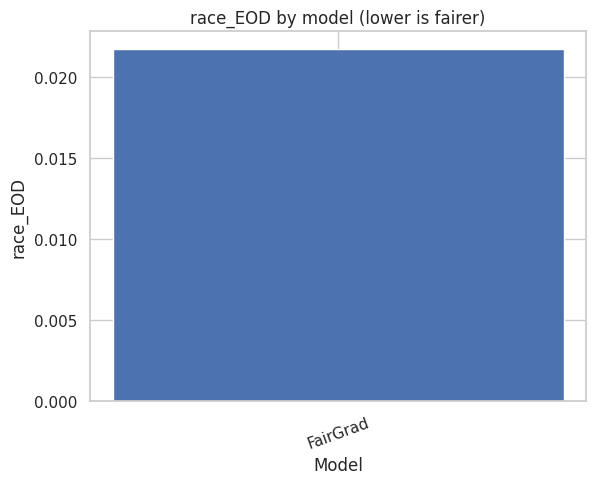

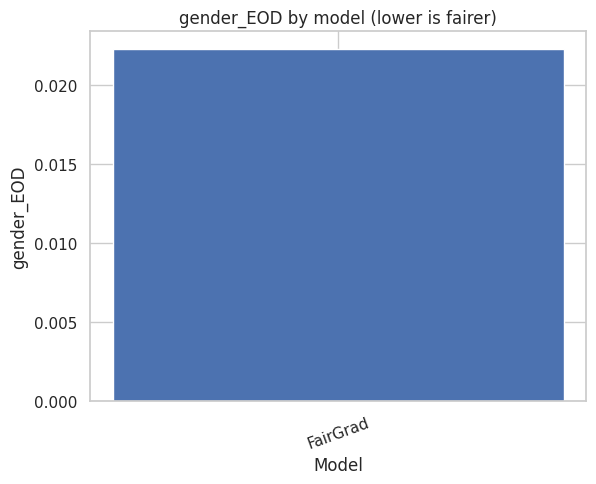

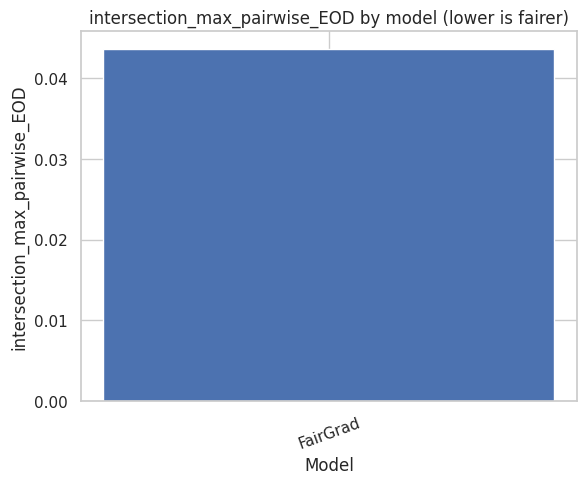

FairGrad
Performance: AUC=0.481, Sensitivity=0.076, Specificity=0.932. Race fairness (EOD)=0.022; lower values indicate smaller TPR/FPR gaps between race groups. Gender fairness (EOD)=0.022; lower values indicate smaller TPR/FPR gaps between genders. Intersection fairness (max pairwise EOD)=0.044, capturing worst-case disparity across race×gender groups. In a clinical risk setting, large TPR/FNR disparities can indicate one group is more likely to be missed (false negatives), which is a patient safety concern.



In [ ]:
# Teammate 3-862554115
#Baseline Models & Performance Metrics
X_all = df.drop(columns=[TARGET_COL]).copy()
X = X_all.drop(columns=SENSITIVE_COLS).copy()
y = df[TARGET_COL].astype(int).values

X_np = X.values
print("X:", X_np.shape, "y:", y.shape)
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=400, random_state=0, class_weight="balanced"
    ),
    "HistGB": HistGradientBoostingClassifier(random_state=0),
    # "FairGrad": FairGrad(fairness_col_indices=[0,1,2], lr=0.41, epochs=100)
}
models
def perf_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)  # sensitivity/TPR
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp + 1e-12)

    return {
        "AUC": auc,
        "Accuracy": acc,
        "Precision": prec,
        "Recall(Sensitivity)": rec,
        "Specificity": spec,
        "F1": f1,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    }
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

perf_rows = []
# for model_name, model in models.items():
#     for fold, (tr, te) in enumerate(skf.split(X_np, y), start=1):
#         model.fit(X_np[tr], y[tr])
#         yprob = model.predict_proba(X_np[te])[:, 1]
#         perf_rows.append({"model": model_name, "fold": fold, **perf_metrics(y[te], yprob)})
for model_name, model in models.items():
    for fold, (tr, te) in enumerate(skf.split(X_all.values, y), start=1):
        model.fit(X_all.values[tr], y[tr])
        yprob = model.predict_proba(X_all.values[te])[:, 1]
        perf_rows.append({"model": model_name, "fold": fold, **perf_metrics(y[te], yprob)})

perf_df = pd.DataFrame(perf_rows)

display(perf_df)
display(perf_df.groupby("model")[["AUC","Accuracy","Precision","Recall(Sensitivity)","Specificity","F1"]].mean().round(4))
# - All three models have similar ability to rank high-risk patients above low-risk ones

# - Recall: Logistic Regression catches 70% of deaths, RF and HistGB catch only 40–45% of deaths
# - All three baseline models achieve comparable AUC (~0.79), indicating similar discrimination performance.
# - Logistic regression achieves the highest recall (0.70), correctly identifying approximately 70% of in-hospital deaths, whereas Random Forest and HistGB achieve recall below 0.45.
# - The tree-based models, on the other hand, achieve higher specificity (>0.90), indicating strong performance in identifying survivors but at the cost of missing high-risk patients.
# - Also, given the clinical importance of minimizing false negatives in mortality prediction, logistic regression provides the most balanced baseline for fairness evaluation
#TEAMMATE 2- 862554121
#Fairness Metrics
#Fairness Metric Functions
def confusion_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    tpr = tp / (tp + fn + 1e-12)
    fpr = fp / (fp + tn + 1e-12)
    ppr = y_pred.mean()
    fnr = fn / (fn + tp + 1e-12)
    return {"TPR": tpr, "FPR": fpr, "PPR": ppr, "FNR": fnr}

def fairness_binary_group(y_true, y_prob, s, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    r0 = confusion_rates(y_true[s == 0], y_pred[s == 0])
    r1 = confusion_rates(y_true[s == 1], y_pred[s == 1])

    dp_diff = r1["PPR"] - r0["PPR"]
    eo_diff = r1["TPR"] - r0["TPR"]
    eod = 0.5 * (abs(r1["TPR"] - r0["TPR"]) + abs(r1["FPR"] - r0["FPR"]))
    fnr_diff = r1["FNR"] - r0["FNR"]

    return {
        "DP_diff": dp_diff,
        "EO_diff(TPR_gap)": eo_diff,
        "EOD": eod,
        "FNR_diff": fnr_diff,
        "group0_TPR": r0["TPR"], "group1_TPR": r1["TPR"],
        "group0_FPR": r0["FPR"], "group1_FPR": r1["FPR"],
        "group0_PPR": r0["PPR"], "group1_PPR": r1["PPR"],
    }
# Demographic Parity (DP): are groups predicted positive at similar rates?

# Equal Opportunity (EO): do groups have similar true positive rates (TPR)? Does the model catch deaths equally well in both groups?

# Equalized Odds Difference (EOD): combines TPR and FPR gaps → lower is fairer.
#Intersection fairness: max pairwise EOD across 4 groups
from itertools import combinations

def max_pairwise_eod_intersection(y_true, y_prob, inter_group, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    groups = np.unique(inter_group)
    rates = {}
    for g in groups:
        mask = inter_group == g
        if mask.sum() == 0:
            continue
        rates[g] = confusion_rates(y_true[mask], y_pred[mask])

    pair_eods = []
    for a, b in combinations(rates.keys(), 2):
        eod = 0.5 * (abs(rates[a]["TPR"] - rates[b]["TPR"]) + abs(rates[a]["FPR"] - rates[b]["FPR"]))
        pair_eods.append((a, b, eod))

    if not pair_eods:
        return np.nan
    return max(pair_eods, key=lambda x: x[2])[2]
#Compute fairness metrics for each baseline
fair_rows = []

for model_name, model in models.items():
    for fold, (tr, te) in enumerate(skf.split(X_np, y), start=1):
        model.fit(X_np[tr], y[tr])
        yprob = model.predict_proba(X_np[te])[:, 1]

        row = {"model": model_name, "fold": fold}

        # race & gender fairness
        for s_col in SENSITIVE_COLS:
            s = df.loc[te, s_col].astype(int).values
            fm = fairness_binary_group(y[te], yprob, s)
            for k, v in fm.items():
                row[f"{s_col}_{k}"] = v

        # intersection group encoding: 2*race + gender => {0,1,2,3}
        race = df.loc[te, "race"].astype(int).values
        gender = df.loc[te, "gender"].astype(int).values
        inter = 2*race + gender
        row["intersection_max_pairwise_EOD"] = max_pairwise_eod_intersection(y[te], yprob, inter)

        fair_rows.append(row)

fair_df = pd.DataFrame(fair_rows)

cols_to_report = [c for c in fair_df.columns if ("DP_diff" in c or "EO_diff" in c or "EOD" in c or "FNR_diff" in c or "intersection_max_pairwise_EOD" in c)]
display(fair_df.groupby("model")[cols_to_report].mean().round(4))
# - There is minimal gender-based disparity in TPR/FPR.
# - Demographic Parity Difference (DP_diff) values are all around -0.008 to 0.02 meaning model predicts death at similar rates across groups.
perf_mean = perf_df.groupby("model")[["AUC","Accuracy","Precision","Recall(Sensitivity)","Specificity","F1"]].mean()
fair_mean = fair_df.groupby("model")[cols_to_report].mean()

final_table = perf_mean.join(fair_mean, how="inner").round(4)
display(final_table)
plot_data = final_table.reset_index()

for metric in ["race_EOD", "gender_EOD", "intersection_max_pairwise_EOD"]:
    if metric not in plot_data.columns:
        continue
    plt.figure()
    plt.bar(plot_data["model"], plot_data[metric])
    plt.title(f"{metric} by model (lower is fairer)")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.show()
def interpret_model(row):
    lines = []
    lines.append(f"Performance: AUC={row['AUC']:.3f}, Sensitivity={row['Recall(Sensitivity)']:.3f}, Specificity={row['Specificity']:.3f}.")
    if "race_EOD" in row:
        lines.append(f"Race fairness (EOD)={row['race_EOD']:.3f}; lower values indicate smaller TPR/FPR gaps between race groups.")
    if "gender_EOD" in row:
        lines.append(f"Gender fairness (EOD)={row['gender_EOD']:.3f}; lower values indicate smaller TPR/FPR gaps between genders.")
    if "intersection_max_pairwise_EOD" in row:
        lines.append(f"Intersection fairness (max pairwise EOD)={row['intersection_max_pairwise_EOD']:.3f}, capturing worst-case disparity across race×gender groups.")
    lines.append("In a clinical risk setting, large TPR/FNR disparities can indicate one group is more likely to be missed (false negatives), which is a patient safety concern.")
    return " ".join(lines)

for _, r in final_table.reset_index().iterrows():
    print("="*90)
    print(r["model"])
    print(interpret_model(r))
    print()
# - Logistic Regression is the most appropriate baseline because it has highest recall.
# - Baseline models are not dramatically unfair.

# - Tree-based models achieve slightly higher overall accuracy but at the cost of substantially reduced sensitivity.

# - Logistic regression offers a more balanced tradeoff between predictive performance and fairness, particularly in intersectional evaluation. Given its higher sensitivity and competitive fairness metrics, logistic regression serves as the most appropriate baseline for fairness-aware training in Phase 4

## Compare Model Performance and Fairness Metrics

We will use both performance and fairness metrics to compare model behavior before and after fairness mitigation. Performance metrics measure predictive accuracy and clinical usefulness, while fairness metrics assess disparities across demographic groups. Together, these metrics allow us to evaluate trade-offs between model performance and fairness.

In [25]:
"""
Model Evaluation Pipeline — Performance and Fairness Metrics
Replicates Table 4 from Wang & Yang (2025), arXiv:2504.14388v1

Package responsibilities:
    sklearn.metrics.roc_auc_score   → AUC
    sklearn.metrics.recall_score    → Sensitivity (TPR) and Specificity (TNR)
    [custom] eod()                  → EOD per Eq. 7 (fairlearn uses max not avg)
    [custom] pf_score()             → P-F Score per Eq. 8 (no standard package)
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, recall_score


NON_SENSITIVE  = ['heart_rate_min', 'heart_rate_max', 'heart_rate_mean', 'glucose_min', 'glucose_max', 
             'glucose_mean', 'sbp_min', 'sbp_max', 'sbp_mean', 'cci', 'apsiii']
SENSITIVE = ['gender', 'age', 'race']
FEATURES  = NON_SENSITIVE + SENSITIVE
TARGET    = 'target'
RACE_IDX  = FEATURES.index('race')
SEX_IDX   = FEATURES.index('gender')


def eod(y_true, y_pred, sensitive):
    # EOD = ½ · (|TPR_a − TPR_b| + |FPR_a − FPR_b|)
    rate  = lambda mask: y_pred[mask].mean() if mask.sum() > 0 else 0.0
    tpr   = lambda s: rate((y_true == 1) & (sensitive == s))
    fpr   = lambda s: rate((y_true == 0) & (sensitive == s))
    return 0.5 * (abs(tpr(1) - tpr(0)) + abs(fpr(1) - fpr(0)))


def pf_score(auc, eod_list):
    # P-F = n · AUC · Π(1 − EOD_i) / (AUC + Σ(1 − EOD_i))
    n, fair = 1 + len(eod_list), [1 - e for e in eod_list]
    return (n * auc * np.prod(fair)) / (auc + sum(fair))


def compute_metrics(y_true, y_prob, race, sex, threshold=0.5):
    y_true = np.array(y_true)
    y_pred = (y_prob >= threshold).astype(int)

    fold_auc    = roc_auc_score(y_true, y_prob)
    sensitivity = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    specificity = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    eod_race  = eod(y_true, y_pred, np.array(race))
    eod_sex   = eod(y_true, y_pred, np.array(sex))
    fold_pf   = pf_score(fold_auc, [eod_race, eod_sex])

    return {
        'AUC':      fold_auc,
        'Sens':     sensitivity,
        'Spec':     specificity,
        'EOD_race': eod_race,
        'EOD_sex':  eod_sex,
        'PF_score': fold_pf,
    }


# ── Pipeline ──────────────────────────────────────────────────────────────────
def evaluate_models(models, df, n_splits=5, seed=42, verbose=True) -> tuple[pd.DataFrame, pd.DataFrame]:
    X_raw = df[FEATURES].values.astype(np.float64)
    y     = df[TARGET].values.astype(np.float64)
    race_raw = X_raw[:, RACE_IDX].copy()
    sex_raw  = X_raw[:, SEX_IDX].copy()

    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []

    for model_name, model in models.items():
        
        if verbose: print(f"\n{'─'*62}\n  {model_name}\n{'─'*62}")

        for fold, (train_idx, test_idx) in enumerate(skf.split(X_raw, y), start=1):
            X_train = X_raw[train_idx]
            X_test  = X_raw[test_idx]
            y_train = y[train_idx]
            y_test  = y[test_idx]
            
            scaler  = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

            model.fit(X_train, y_train)
            y_prob = model.predict_proba(X_test)[:, 1]

            fold_metrics = compute_metrics(
                y_test, y_prob,
                race=race_raw[test_idx],    # raw values, not scaled
                sex=sex_raw[test_idx],
            )

            rows.append({'model': model_name, 'fold': fold, **fold_metrics})
            
            if verbose: print(f"  Fold {fold} | " + " | ".join(f"{k}={v:.4f}" for k, v in fold_metrics.items()))

    results_df  = pd.DataFrame(rows)
    metric_cols = ['AUC', 'Sens', 'Spec', 'EOD_race', 'EOD_sex', 'PF_score']
    summary     = results_df.groupby('model')[metric_cols].agg(['mean', 'std']).round(4)

    if verbose: 
        print(f"\n{'═'*62}\n  Summary — mean ± std across {n_splits} folds\n{'═'*62}")
        print(summary.to_string())

    return results_df, summary

In [27]:
import numpy as np

# Best learning rate: 0.21 with mean P-F Score: 0.5459
learning_rates = np.array([0.00001, 0.0001, 0.001, 0.01, 0.1 , 1, 10])
best_lr      = None
best_pf      = -np.inf
lr_results   = []

for lr in learning_rates:
    model = FairGrad(fairness_col_indices=[0,1,2], lr=lr, epochs=100)
    _, summary = evaluate_models({'FairGrad': model}, df_sepsis, n_splits=5, verbose=False)
    mean_pf = summary.loc['FairGrad', ('PF_score', 'mean')]

    lr_results.append({'lr': lr, 'pf_score': mean_pf})

    if mean_pf > best_pf:
        best_pf = mean_pf
        best_lr = lr

    print(f"lr={lr:.5f} | PF_score={mean_pf:.4f} | best so far: lr={best_lr:.2f} ({best_pf:.4f})")

print(f"\nBest learning rate: {best_lr:.2f} with mean P-F Score: {best_pf:.4f}")

lr_df = pd.DataFrame(lr_results)

lr=0.00001 | PF_score=0.4088 | best so far: lr=0.00 (0.4088)
lr=0.00010 | PF_score=0.4790 | best so far: lr=0.00 (0.4790)
lr=0.00100 | PF_score=0.4584 | best so far: lr=0.00 (0.4790)
lr=0.01000 | PF_score=0.5180 | best so far: lr=0.01 (0.5180)
lr=0.10000 | PF_score=0.4805 | best so far: lr=0.01 (0.5180)
lr=1.00000 | PF_score=0.4563 | best so far: lr=0.01 (0.5180)
lr=10.00000 | PF_score=0.4653 | best so far: lr=0.01 (0.5180)

Best learning rate: 0.01 with mean P-F Score: 0.5180


In [ ]:
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=400, random_state=0, class_weight="balanced"
    ),
    "HistGB": HistGradientBoostingClassifier(random_state=0),
    "FairGrad": FairGrad(fairness_col_indices=[0,1,2], lr=0.21, epochs=100),
    
    ###TODO: Uncomment after implementation
    # "Vanilla": Vanilla(),
    # "AdversLearn": AdversLearn(),
    # "Reduction": Reduction()
}
df = df_sepsis

results_df, summary = evaluate_models(models, df)

  Fold 1 | AUC=0.4875 | Sens=0.6551 | Spec=0.3280 | EOD_race=0.2534 | EOD_sex=0.3656 | PF_score=0.3707
  Fold 2 | AUC=0.3069 | Sens=0.1769 | Spec=0.5843 | EOD_race=0.4261 | EOD_sex=0.1383 | PF_score=0.2613
  Fold 3 | AUC=0.5325 | Sens=0.6518 | Spec=0.3825 | EOD_race=0.3864 | EOD_sex=0.0516 | PF_score=0.4439
  Fold 4 | AUC=0.5517 | Sens=0.5165 | Spec=0.5633 | EOD_race=0.1495 | EOD_sex=0.2528 | PF_score=0.4894
  Fold 5 | AUC=0.3356 | Sens=0.4241 | Spec=0.3322 | EOD_race=0.2105 | EOD_sex=0.1590 | PF_score=0.3400
  Fold 1 | AUC=0.7768 | Sens=0.6898 | Spec=0.7249 | EOD_race=0.0085 | EOD_sex=0.0130 | PF_score=0.8277
  Fold 2 | AUC=0.7820 | Sens=0.7041 | Spec=0.7149 | EOD_race=0.0388 | EOD_sex=0.0343 | PF_score=0.8039
  Fold 3 | AUC=0.7919 | Sens=0.6716 | Spec=0.7441 | EOD_race=0.0488 | EOD_sex=0.0329 | PF_score=0.8064
  Fold 4 | AUC=0.7986 | Sens=0.6997 | Spec=0.7448 | EOD_race=0.0422 | EOD_sex=0.0368 | PF_score=0.8127
  Fold 5 | AUC=0.8024 | Sens=0.7079 | Spec=0.7361 | EOD_race=0.0437 | EOD

## Results and Discussion